In [1]:
"""
Incorporation of IMERG data into the ERA5 format so that Graphcast can finetune over it
"""

import xarray as xr
import numpy as np
import sys
sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
import trainer.dataloader

In [2]:
# Copyright 2024 Crown in Right of Canada
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS-IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

## PrioritizedItem wrapper for the output priority queue
from dataclasses import dataclass, field
from typing import Any

debug_prints = False
import datetime

import threading
compute_lock = threading.Lock()

# Cache to split up a database into dask-manageable chunks on the fly.  The structure here is:
# {dbase_key(dbase), {bucket1 : optimized_subset1, bucket2 : optimized_subset2, etc}}
# Use collections.defaultdict to set a default value of an empty dictionary
import collections
dbase_cache = collections.defaultdict(dict)

def dbase_key(dbase):
    '''XArrays are mutable and unhashable, but we don't really mutate the databases after
    loading them.  Thus, define dbase_key to create a reasonably unique key to represent a
    potentially multi-file database, based on the source filename, key dimension sizes,
    and starting time'''
    # return ((dbase.encoding['source'], # source filename
    #          dbase.time.size, 
    #          dbase.latitude.size,
    #          dbase.longitude.size,
    #          dbase.time[0].data.item()))
    return ((dbase.time.size, 
            dbase.latitude.size,
            dbase.longitude.size,
            dbase.time[0].data.item()))

def dbase_load(dbase,input_variables,time_idx,level_idx,lat_idx=None,lon_idx=None):
    # Load a specified set of input_variables from a database, selecting a scalar time_idx
    # and subsetting by level_idx, lat_idx, and lon_idx (if latter two are provided and
    # not None).  This uses the global dbase_cache, and lazily creates dask-optimized
    # database subsets as necessary
    import dask
    import xarray as xr

    global dbase_cache

    # Find out what time bucket time_idx lies in
    TIME_BUCKET_SIZE = 1000
    time_bucket = time_idx // TIME_BUCKET_SIZE

    # Get the set of database subsets from the cache corresponding to the provided
    # database.  The result is a mutable dictionary, so changes (additions) to
    # dbase_subsets should be immediately reflected inside dbase_cache
    dbase_subsets = dbase_cache[dbase_key(dbase)]

    # Search for the proper bucket inside dbase_subsets.
    if (time_bucket not in dbase_subsets):
        # If not present, slice dbase along the time dimension
        subset = dbase.isel(time=slice(TIME_BUCKET_SIZE*time_bucket,TIME_BUCKET_SIZE*(time_bucket+1)))
        # dask.optimize, to keep the data unloaded but remove references ot out-of-scope times
        subset = dask.optimize(subset)[0]
        # Write the now-optimized subset back to the cache
        dbase_subsets[time_bucket] = subset
    else:
        # Just load the subset from the cache
        subset = dbase_subsets[time_bucket]

    # Get time_idx with respect to the beginning of this subset
    subset_time_idx = time_idx % TIME_BUCKET_SIZE

    # Check to see if we have conforming latitude/longitudes, using all indices in the dataset in-order
    if (lat_idx is None): assert(lon_idx is None)
    conforming_latlon = (lat_idx is None)

    # Load input_variables from the selected subset

    # Create a skeletal output dataset
    if (conforming_latlon):
        inputs = xr.Dataset(coords={'time':subset.time[[subset_time_idx]].data,
                            'level':subset.level[level_idx],
                            'latitude':subset.latitude,
                            'longitude':subset.longitude}) 
    else:
        inputs = xr.Dataset(coords={'time':subset.time[[subset_time_idx]].data,
                            'level':subset.level[level_idx],
                            'latitude':subset.latitude[lat_idx],
                            'longitude':subset.longitude[lon_idx]}) 

    # Assign loaded variables to the input dataset
    for var in input_variables:
        # print(var)
        # print(f"Variable: {var}")
        # print(f"subset[var].shape: {subset[var].shape}")
        # print(f"subset_time_idx: {subset_time_idx}")
        if 'time' in subset[var].dims:
            if 'level' in subset[var].dims:
                # XArray "doesn't support yet fancy nd indexing", so we need to slice the data one dimension at a time
                if (conforming_latlon == True):
                    inputs[var] = (subset[var].dims, subset[var].data[[subset_time_idx],...][:,level_idx,:,:])
                else:
                    inputs[var] = (subset[var].dims, subset[var].data[[subset_time_idx],...][:,level_idx,...][...,lat_idx,:][...,lon_idx])
            else:
                if (conforming_latlon == True):
                    inputs[var] = (subset[var].dims, subset[var].data[[subset_time_idx],...])
                else:
                    inputs[var] = (subset[var].dims, subset[var].data[[subset_time_idx],...][...,lat_idx,:][...,lon_idx])
        else:
            # No support yet for static 3D variables
            assert ('level' not in subset[var].dims)
            if (conforming_latlon == True):
                inputs[var] = subset[var]
            else:
                inputs[var] = (subset[var].dims, subset[var].data[...,lat_idx,:][...,lon_idx])
                
    return inputs
    
    

# Flags to mark whether we've warned for noncomforming lat/lon coordinates
warned_v_conforming_latlon = False
warned_a_conforming_latlon = False

def build_forecast(idate,forecast_length,task_config,
                   model_latitude, model_longitude, input_variables, target_variables,
                   a_dbase, v_dbase, do_compute = False):
    # from forecast import 
    import forecast.forecast_variables
    from forecast.toa_radiation import toa_radiation
    from forecast import forecast_prep
    from forecast import encabulator
    import datetime
    import numpy as np
    import xarray as xr
    import dask
    import warnings
    dt = datetime.timedelta(hours=6)

    global warned_a_conforming_latlon
    global warned_v_conforming_latlon

    # Work on copies of the databases
    # compute_lock.acquire()
    # a_dbase = a_dbase.copy()
    # v_dbase = v_dbase.copy()
    # compute_lock.release()

    atimes = [idate - dt, idate]
    ftimes = [idate + i*dt for i in range(1,forecast_length+1)]

    atimes_ns = np.array(atimes,dtype='datetime64[ns]')
    ftimes_ns = np.array(ftimes,dtype='datetime64[ns]')
    # print(atimes_ns)

    input_levels = sorted(list(task_config.pressure_levels))

    # Manually convert levels and times to integer indices in the
    # databases, to use .isel rather than .sel for selection.
    try:
        a_level_idx = np.searchsorted(a_dbase.level.data,input_levels)
        assert(all(a_dbase.level.data[a_level_idx] == input_levels))
        
        v_level_idx = np.searchsorted(v_dbase.level.data,input_levels)    
        assert(all(v_dbase.level.data[v_level_idx] == input_levels))

        a_time_idx = np.searchsorted(a_dbase.time.data, atimes_ns)

        print("Printing a_dbase time data")

        print(a_dbase.time.data[a_time_idx])
        print()
        print(atimes_ns)

        print(f"V_Dbase time data: {v_dbase.time.data[v_time_idx]}\n")
        print(f"ftimes_ns: {ftimes_ns}")




        assert(all(a_dbase.time.data[a_time_idx] == atimes_ns))
        v_time_idx = np.searchsorted(v_dbase.time.data,ftimes_ns)

        assert(all(v_dbase.time.data[v_time_idx] == ftimes_ns))


    except Exception as e:
        print(f'Error (database availability) when loading forecast of length {forecast_length} for {idate}')
        raise

    # # Create skeletal analysis
    # inputs = xr.Dataset(coords={'time':atimes_ns,
    #                     'level':input_levels,
    #                     'latitude':model_latitude,
    #                     'longitude':model_longitude}) 
    
    # assert(latitude[0] == a_dbase.latitude[0])
    # assert(longitude[0] == a_dbase.longitude[0])

    # Test to see if the model lat/lon exactly match the dataset
    if (model_latitude.size == a_dbase.latitude.size and \
        model_longitude.size == a_dbase.longitude.size and \
        np.all(model_latitude.data == a_dbase.latitude.data) and \
        np.all(model_longitude.data == a_dbase.longitude.data)):
        a_lat_idx = None
        a_lon_idx = None
        a_conforming_latlon = True
    else:
        # Assert that lat/lon of the model are a subset of the dataset
        assert(np.all(np.isin(model_latitude.data,a_dbase.latitude.data)))
        assert(np.all(np.isin(model_longitude.data,a_dbase.longitude.data)))
        # Assert that the database latitude/longitude are in increasing order
        assert(np.all(np.diff(a_dbase.latitude.data) > 0))
        assert(np.all(np.diff(a_dbase.longitude.data) > 0))
        if (not warned_a_conforming_latlon):
            warnings.warn('Analysis/IC dataset is higher resolution than the model; using indexed loading')
            warned_a_conforming_latlon = True
        a_conforming_latlon = False
        a_lat_idx = np.searchsorted(a_dbase.latitude.data,model_latitude.data)
        a_lon_idx = np.searchsorted(a_dbase.longitude.data,model_longitude.data)

    # Test to see if the model lat/lon exactly match the dataset
    if (model_latitude.size == v_dbase.latitude.size and \
        model_longitude.size == v_dbase.longitude.size and \
        np.all(model_latitude.data == v_dbase.latitude.data) and \
        np.all(model_longitude.data == v_dbase.longitude.data)):
        v_lat_idx = None
        v_lon_idx = None
        v_conforming_latlon = True
    else:
        # Assert that lat/lon of the model are a subset of the dataset
        assert(np.all(np.isin(model_latitude.data,v_dbase.latitude.data)))
        assert(np.all(np.isin(model_longitude.data,v_dbase.longitude.data)))
        # Assert that the database latitude/longitude are in increasing order
        assert(np.all(np.diff(v_dbase.latitude.data) > 0))
        assert(np.all(np.diff(v_dbase.longitude.data) > 0))
        if (not warned_v_conforming_latlon):
            warnings.warn('Validation/target dataset is higher resolution than the model; using indexed loading')
            warned_v_conforming_latlon = True
        v_conforming_latlon = False
        v_lat_idx = np.searchsorted(v_dbase.latitude.data,model_latitude.data)
        v_lon_idx = np.searchsorted(v_dbase.longitude.data,model_longitude.data)

    avars_present = list(set.intersection(set(a_dbase.data_vars),input_variables))
    # inputs[avars_present] = a_dbase[avars_present].isel(time=a_time_idx,level=a_level_idx).compute()
    # for var in avars_present:
    #     # print(var)
    #     if 'time' in a_dbase[var].dims:
    #         if 'level' in a_dbase[var].dims:
    #             # XArray "doesn't support yet fancy nd indexing", so we need to slice the data one dimension at a time
    #             if (a_conforming_latlon == True):
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...][:,a_level_idx,:,:])
    #             else:
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...][:,a_level_idx,...][...,a_lat_idx,:][...,a_lon_idx])
    #         else:
    #             if (a_conforming_latlon == True):
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...])
    #             else:
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...][...,a_lat_idx,:][...,a_lon_idx])

    inputs = xr.concat( [dbase_load(a_dbase,avars_present,tt,a_level_idx,a_lat_idx,a_lon_idx) for tt in a_time_idx],
                       coords='minimal',compat='override',dim='time')

    if ('toa_incident_solar_radiation') not in avars_present:
        # Since toa_radiation is being called based on a copy of the input coordinates, we don't
        # have to worry below that time becomes a relative value; contrast the special handling
        # for forcings
        inputs['toa_incident_solar_radiation'] = (('time','latitude','longitude'),
                                                    dask.array.from_delayed(dask.delayed(toa_radiation)(xr.Dataset(inputs.coords.copy())),
                                                                            shape=(inputs.time.size,inputs.latitude.size,inputs.longitude.size),
                                                                            dtype=np.float32))
        
    if ('day_progress_cos' not in avars_present):
        forecast_prep.add_progress(inputs)

        
    forcings = xr.Dataset(coords={'time':ftimes_ns,
                        'level':input_levels,
                        'latitude':model_latitude,
                        'longitude':model_longitude}) 
    # targets = xr.Dataset(coords={'time':ftimes_ns,
    #                     'level':input_levels,
    #                     'latitude':model_latitude,
    #                     'longitude':model_longitude}) 
    tvars_present = list(set.intersection(set(v_dbase.data_vars),target_variables))

    # print(ftimes_ns)

    targets = xr.concat( [dbase_load(v_dbase,tvars_present,tt,v_level_idx,v_lat_idx,v_lon_idx) for tt in v_time_idx],
                        coords='minimal',compat='override',dim='time')
    
    # for var in tvars_present:
    #     if 'time' in v_dbase[var].dims:
    #         if 'level' in v_dbase[var].dims:
    #             if (v_conforming_latlon == True):
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...][:,v_level_idx,...])
    #             else:
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...][:,v_level_idx,...][...,v_lat_idx,:][...,v_lon_idx])
    #         else:
    #             if (v_conforming_latlon == True):
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...])
    #             else:
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...][...,v_lat_idx,:][...,v_lon_idx])
    # targets[tvars_present] = v_dbase[tvars_present].isel(time=v_time_idx,level=v_level_idx).compute()

    # As with radiation for the inputs, call toa_radiation on a skeletal dataset made from coordinate copies;
    # this avoids problems when the coordinates are modified subsequently but before(/during?) radiation calculation
    forcings['toa_incident_solar_radiation'] = (('time','latitude','longitude'),
                                                dask.array.from_delayed(dask.delayed(toa_radiation)(xr.Dataset(forcings.coords.copy())),
                                                                        shape=(forcings.time.size,forcings.latitude.size,forcings.longitude.size),
                                                                        dtype=np.float32))
    forecast_prep.add_progress(forcings)

    # Graphcast uses the 'time' dimension for relative time; preserve the original analysis/validity time as
    # a 'datetime' coordinate.
    i_reltime = atimes_ns - atimes_ns[-1]
    inputs['time'] = i_reltime
    inputs.coords['datetime'] = ('time',atimes_ns)

    f_reltime = ftimes_ns - atimes_ns[-1]
    forcings['time'] = f_reltime
    targets['time'] = f_reltime
    forcings.coords['datetime'] = ('time',ftimes_ns)
    targets.coords['datetime'] = ('time',ftimes_ns)

    # Prepend a 'batch' dimension and rename 'latitude' and 'longitude' to 'lat' and 'lon'
    renames = {'latitude': 'lat', 'longitude' : 'lon'}
    inputs = inputs.expand_dims(dim='batch').rename(renames)
    forcings = forcings.expand_dims(dim='batch').rename(renames)
    targets = targets.expand_dims(dim='batch').rename(renames)
    
    fixed_input_vars = set.intersection(set(forecast.forecast_variables.FIXED_VARIABLES),set(input_variables))
    inputs[fixed_input_vars] = inputs[fixed_input_vars].isel(batch=0,time=0,drop=True)

    # inputs, targets, forcings = dask.optimize(inputs,targets,forcings)

    if (do_compute):
        (inputs, forcings, targets) = dask.compute(*(inputs,forcings,targets))
    
    return(inputs, forcings, targets)



@dataclass(order=True)
class PrioritizedItem:
    priority: int
    item: Any=field(compare=False)

def open_one_database(path_glob):
    import xarray as xr
    import glob
    import numpy as np
    from forecast import encabulator
    import dask
    import warnings

    # Suppress ECCodes warning
    with warnings.catch_warnings(action="ignore"):
        dbase_paths = sorted(list(glob.glob(f'{path_glob}/*/*')))
        print(f"Found {dbase_paths} files in {path_glob}")

        # * Open each month separately
        # * Drop toa_incident_solar_radiation if present (it's not consistently present and causes bad chunking on merge)
        # * set a chunk size of 1 in time
        dbase_by_month = [xr.open_dataset(path,cache=False,engine='zarr').chunk(time=1) for path in dbase_paths]
        dbase_by_month_norad = [ d[[v for v in d.data_vars if v != 'toa_incident_solar_radiation']] for d in dbase_by_month ]

    # Concatenate each moth together. compat='override' takes the first-encountered value for variables that are time-independent
    # like geopotential_at_surface.  join='override' was once present but is erroneous; it breaks if there's a different coordinate
    # ordering between months -- this happens with ERA5 data downloaded from weatherbench versus cds
    print("Concatenating monthly databases")
    # print(dbase_by_month_norad)
    # print(f"\n == {dbase_by_month_norad[0].time} == \n")

    dbase = xr.concat(dbase_by_month_norad, dim='time', coords='minimal', data_vars='minimal', compat='override')

    # Drop any time duplicates
    dbase = dbase.drop_duplicates(dim='time')

    # Finally, dask-optimize the combined dataset, saving a bit of time later on when picking out individual elements
    dbase = dask.optimize(dbase)[0]
    return dbase

def open_databases(a_dbase_path, v_dbase_path):
    import xarray as xr
    import glob
    import numpy as np
    # Ensure loading of compression codec
    from forecast import encabulator
    import dask # For graph optimization
    import warnings

    a_dbase = open_one_database(a_dbase_path)

    # Assert that levels and times are sorted
    if a_dbase.level.data[0] > a_dbase.level.data[1]:
        a_dbase = a_dbase.sortby('level', ascending=True)
    assert(all(np.sort(a_dbase.level.data) == a_dbase.level.data))
    assert(all(np.sort(a_dbase.time.data) == a_dbase.time.data))

    # ## Preload time-independent fields
    # for var in a_dbase.data_vars:
    #     if 'time' not in a_dbase[var].dims:
    #         a_dbase[var] = a_dbase[var].compute()

    if (a_dbase_path == v_dbase_path):
        v_dbase = a_dbase
    elif (v_dbase_path is None):
        v_dbase = None
    else:
        v_dbase = open_one_database(v_dbase_path)
        assert(all(np.sort(v_dbase.level.data) == v_dbase.level.data))
        assert(all(np.sort(v_dbase.time.data) == v_dbase.time.data))

    return (a_dbase, v_dbase)


def mp_consumer(job_queue, output_queue, forecast_length, params_path,
                a_dbase, v_dbase,proc_number):

    # all_procs = sorted(list(os.sched_getaffinity(0)))
    # if (len(all_procs) > proc_number+1):
    #     target_proc = all_procs[proc_number+1]
    #     os.sched_setaffinity(0,[target_proc])
    #     print(f'Proc {proc_number} pinned to processor {target_proc}')

    # os.environ['OMP_NUM_THREADS']='1'
    # os.environ['MKL_NUM_THREADS']='1'
    import xarray as xr
    from forecast import generate_model
    from forecast.models import models, models_dict
    import numpy as np
    
    import glob
    import dask

    # (a_dbase, v_dbase) = open_databases(a_dbase_path,v_dbase_path)

    (_, task_config, _) = generate_model.load_model(params_path)
    input_variables = set(task_config['input_variables'])
    target_variables = set(task_config['target_variables']) # things produced by graphcast, at t6
    # forcing_variables = set(task_config['forcing_variables']) # things privded as input, at t6

    latitude = a_dbase.latitude.compute()
    longitude = a_dbase.longitude.compute()

    while True:
        pcommand = job_queue.get()
        command = pcommand.item
        try:
            match command[0]:
                case 'terminate':
                    # print(f'Thread {proc_number} terminating')
                    return
                case 'build_example':
                    idate = command[1]
                    if (debug_prints):
                        print(f'Thread {proc_number} building {idate.strftime("%Y%m%d+%HZ")}')
                    tic = datetime.datetime.now()
                    # compute_lock.acquire()
                    (ids,fds,tds) = build_forecast(idate,forecast_length,task_config,
                                                latitude,longitude,
                                                input_variables,target_variables,
                                                a_dbase,v_dbase,False)
                    # compute_lock.release()
                    # datestamp = idate.strftime('%Y%m%d%H')
                    # print(f'Proc {proc_number} writing {idate.strftime("%Y%m%d+%HZ")}')
                    # dask.compute(ids,fds,tds)
                    toc = datetime.datetime.now()
                    tdelta = (toc-tic).total_seconds()
                    if (debug_prints):
                        print(f'Thread {proc_number} submitting {idate.strftime("%Y%m%d+%HZ")} tdelta {tdelta:.3f}s')
                    # output_queue.put((ifname,ffname,tfname,tdelta))
                    # Enqueue the example to the output queue, wrapped as a PrioritizedItem
                    out_item = PrioritizedItem(priority=0,
                                            item=('example',{'input' : ids,
                                                'forcing' : fds,
                                                'target' : tds,
                                                'timedelta' : tdelta}))
                    output_queue.put(out_item)
                    del out_item, ids, fds, tds
                    # output_queue.put((ids,fds,tds,tdelta))
                    # if (debug_prints):
                    #     print(f'Thread {proc_number} written {idate.strftime("%Y%m%d+%HZ")}')
                    # output_lock.release()
                case 'build_minibatch':
                    # Directly construct a minibatch, given a sequence of input dates
                    idate_seq = command[1]
                    inputs = []; targets = []; forcings = []
                    tic = datetime.datetime.now()
                    if (debug_prints):
                        print(f'Thread {proc_number} computing minibatch {" ".join(idate.strftime("%Y%m%d+%HZ") for idate in idate_seq)}')
                    for idate in idate_seq:
                        (ids,fds,tds) = build_forecast(idate,forecast_length,task_config,
                                                    latitude,longitude,
                                                    input_variables,target_variables,
                                                    a_dbase,v_dbase,False)
                        inputs.append(ids)
                        forcings.append(fds)
                        targets.append(tds)
                        del ids, fds, tds
                    input_ds = xr.concat(inputs,dim='minibatch',coords=['datetime'])
                    forcing_ds = xr.concat(forcings,dim='minibatch',coords=['datetime'])
                    target_ds = xr.concat(targets,dim='minibatch',coords=['datetime'])
                    del inputs, forcings, targets
                    # Dask.compute sometimes fails with an internal error; this remains not fully solved.
                    # Retry the computation up to 5 times
                    for retry in range(5):
                        try:
                            (input_ds,forcing_ds,target_ds) = dask.compute(*(input_ds,forcing_ds,target_ds))
                            break
                        except Exception as e:
                            import time
                            if (retry == 0):
                                print(f'Warning: thread {proc_number} received exception {e=} in dask.compute, retrying')
                                time.sleep(0.1)
                            elif (retry < 4):
                                print(f'Warning: thread {proc_number} received exception again, retry {retry+1}')
                                time.sleep(0.1)
                            else: # (retry == 4):
                                # import traceback
                                # traceback.print_exception(type(e), e, e.__traceback__)
                                raise(e) # Reraise exception after 5 attempts

                    toc = datetime.datetime.now()
                    tdelta = (toc-tic).total_seconds()

                    if (debug_prints):
                        print(f'Thread {proc_number} submitting minibatch {" ".join(idate.strftime("%Y%m%d+%HZ") for idate in idate_seq)}')

                    out_item = PrioritizedItem(priority=1,item=('minibatch',{'inputs' : input_ds,
                                                'forcings' : forcing_ds,
                                                'targets' : target_ds,
                                                'timedelta' : tdelta}))
                    output_queue.put(out_item)
                    del out_item, input_ds, forcing_ds, target_ds           
                case 'assemble_minibatch':

                    tic = datetime.datetime.now()
                    inputs = command[1].get('inputs',None)
                    targets = command[1].get('targets',None)
                    forcings = command[1].get('forcings',None)

                    # input_minibatch = xr.concat(input_minibatch_list,dim='minibatch',coords=['datetime'])
                    # forcing_minibatch = xr.concat(forcing_minibatch_list,dim='minibatch',coords=['datetime'])
                    # target_minibatch = xr.concat(target_minibatch_list,dim='minibatch',coords=['datetime'])


                    # idate_seq = np.array(input_ds.datetime[...,-1].data,dtype='datetime64[s]').astype(datetime.datetime).reshape((-1,))
                    if (inputs is not None and inputs[0] is not None):
                        idate_seq = [ ind.datetime.data.astype('datetime64[s]').astype(datetime.datetime)[-1] for ind in inputs ]
                        if (debug_prints):
                            print(f'Thread {proc_number} assembling minibatch {" ".join(idate.strftime("%Y%m%d+%HZ") for idate in idate_seq)}')

                        input_ds = xr.concat(inputs,dim='minibatch',coords=['datetime'])
                    else:
                        input_ds = None

                    if forcings is not None and forcings[0] is not None:
                        forcing_ds = xr.concat(forcings,dim='minibatch',coords=['datetime'])
                    else:
                        forcing_ds = None

                    if targets is not None and targets[0] is not None:
                        target_ds = xr.concat(targets,dim='minibatch',coords=['datetime'])
                    else:
                        target_ds = None

                    # compute_lock.acquire()
                    if (debug_prints):
                        print(f'Thread {proc_number} assembling minibatch {" ".join(idate.strftime("%Y%m%d+%HZ") for idate in idate_seq)}')
                    for retry in range(5):
                        try:
                            (input_ds, forcing_ds, target_ds) = dask.compute(*(input_ds,forcing_ds,target_ds))
                            break
                        except Exception as e:
                            print(f'Thread {proc_number} received exception {e=} computing minibatch {" ".join(idate.strftime("%Y%m%d+%HZ") for idate in idate_seq)}, retry {retry}')
                            if (retry == 4):
                                raise(e)
                            
                    # compute_lock.release()
                    del inputs, forcings, targets


                    toc = datetime.datetime.now()
                    tdelta = (toc-tic).total_seconds()

                    if (debug_prints):
                        print(f'Thread {proc_number} submitting minibatch {" ".join(idate.strftime("%Y%m%d+%HZ") for idate in idate_seq)} tdelta {tdelta:.3f}s')


                    out_item = PrioritizedItem(priority=1,item=('minibatch',{'inputs' : input_ds,
                                                'forcings' : forcing_ds,
                                                'targets' : target_ds,
                                                'timedelta' : tdelta}))
                    output_queue.put(out_item)
                    del out_item, input_ds, forcing_ds, target_ds

                case _:
                    print(f'Thread {proc_number} unknown {command=}')
                    raise(NotImplementedError())
                
        except Exception as e:
            print(f'Thread {proc_number} received exception {e=}')
            import traceback
            traceback.print_exception(type(e), e, e.__traceback__)
            output_queue.put(PrioritizedItem(priority=-999,item=('exception',None)))
            raise(e)


In [33]:
start_year = '2014'

In [35]:

apath = '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache'
dbase,_ = trainer.dataloader.open_databases(apath,None)
era_ds = dbase.sel(time=slice(f'{start_year}-01-01',None ))
del dbase
era_ds

Found 41 files in /Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache
Concatenating monthly databases


<xarray.Dataset> Size: 292GB
Dimensions:                  (time: 4941, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
    expver                   (time) <U4 79kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                   int64 8B ...
  * time                     (time) datetime64[ns] 40kB 2014-01-01 ... 2025-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    land_sea_mask            (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-05T06:24 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [58]:
imerg_ds_initial = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_dir/combined2014_imerg1deg.nc')
imerg_ds_initial

<xarray.Dataset> Size: 382MB
Dimensions:        (time: 365, lon: 361, lat: 181)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2014-01-01 ... 2014-12-31
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables:
    precipitation  (time, lon, lat) float64 191MB ...
    randomError    (time, lon, lat) float64 191MB ...
Attributes:
    BeginDate:       2014-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2014-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2014-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20140101-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2024-01-12T13:09:09.320Z

In [50]:
imerg_ds_initial.time.values

array(['2024-01-01T00:00:00.000000000', '2024-01-02T00:00:00.000000000',
       '2024-01-03T00:00:00.000000000', '2024-01-04T00:00:00.000000000',
       '2024-01-05T00:00:00.000000000', '2024-01-06T00:00:00.000000000',
       '2024-01-07T00:00:00.000000000', '2024-01-08T00:00:00.000000000',
       '2024-01-09T00:00:00.000000000', '2024-01-10T00:00:00.000000000',
       '2024-01-11T00:00:00.000000000', '2024-01-12T00:00:00.000000000',
       '2024-01-13T00:00:00.000000000', '2024-01-14T00:00:00.000000000',
       '2024-01-15T00:00:00.000000000', '2024-01-16T00:00:00.000000000',
       '2024-01-17T00:00:00.000000000', '2024-01-18T00:00:00.000000000',
       '2024-01-19T00:00:00.000000000', '2024-01-20T00:00:00.000000000',
       '2024-01-21T00:00:00.000000000', '2024-01-22T00:00:00.000000000',
       '2024-01-23T00:00:00.000000000', '2024-01-24T00:00:00.000000000',
       '2024-01-25T00:00:00.000000000', '2024-01-26T00:00:00.000000000',
       '2024-01-27T00:00:00.000000000', '2024-01-28

In [59]:
import pandas as pd
date_series = pd.to_datetime(imerg_ds_initial.time.values)

# Extract year and count occurrences
year_counts = date_series.year.value_counts()

In [ ]:
dates_2014 = date_series[date_series.year == 2014]
dates_2014

DatetimeIndex(['2014-01-01', '2014-01-02', '2014-01-03', '2014-01-04',
               '2014-01-05', '2014-01-06', '2014-01-07', '2014-01-08',
               '2014-01-09', '2014-01-10',
               ...
               '2014-12-22', '2014-12-23', '2014-12-24', '2014-12-25',
               '2014-12-26', '2014-12-27', '2014-12-28', '2014-12-29',
               '2014-12-30', '2014-12-31'],
              dtype='datetime64[ns]', length=365, freq=None)

In [ ]:
dates_2014[dates_2014.month == 7]

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [61]:
len(imerg_ds_initial.lon.values)

361

In [56]:
imerg_ds_initial

<xarray.Dataset> Size: 383MB
Dimensions:        (time: 366, lon: 361, lat: 181)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables:
    precipitation  (time, lon, lat) float64 191MB ...
    randomError    (time, lon, lat) float64 191MB ...
Attributes:
    BeginDate:       2024-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2024-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2024-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20240101-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2024-06-12T14:19:57.862Z

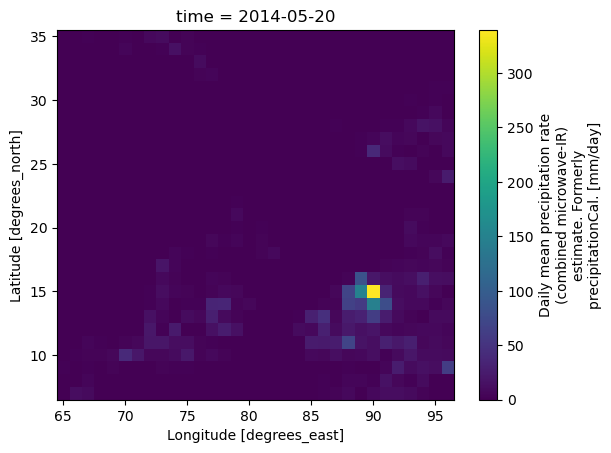

In [62]:
imerg_ds_initial['precipitation'].sel(lat=slice(35, 7), lon=slice(65, 96)).sel(time='2014-05-20').plot(x='lon', y='lat')

In [67]:
imerg_ds_initial = imerg_ds_initial.where(imerg_ds_initial.lon != 180.0, drop=True)
len(imerg_ds_initial.lon.values)

360

In [68]:
imerg_ds = imerg_ds_initial

imerg_ds = imerg_ds_initial.assign_coords(lon=(imerg_ds_initial.lon + 360) % 360)
imerg_ds = imerg_ds.sortby("lon")
imerg_ds = imerg_ds.sortby("lat")

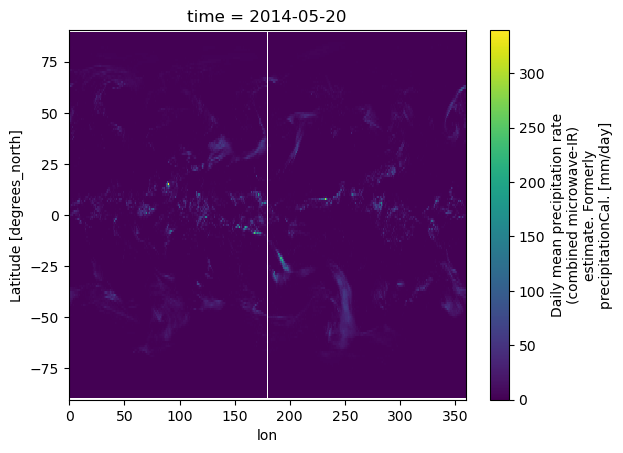

In [69]:
imerg_ds['precipitation'].sel(time=f'{start_year}-05-20').plot(x='lon', y='lat')

In [70]:
era5_times = era_ds.time
imerg_6hr = xr.Dataset(
    data_vars={
        "precipitation_6hr": (("time", "latitude", "longitude"), 
                            np.zeros((len(era5_times), len(era_ds.latitude), len(era_ds.longitude))))
    },
    coords={
        "time": era5_times,
        "longitude": era_ds.longitude,
        "latitude": era_ds.latitude
    }
)
imerg_6hr

<xarray.Dataset> Size: 3GB
Dimensions:            (time: 4941, latitude: 181, longitude: 360)
Coordinates:
    expver             (time) <U4 79kB dask.array<chunksize=(1,), meta=np.ndarray>
    number             int64 8B 0
  * time               (time) datetime64[ns] 40kB 2014-01-01 ... 2025-05-31T1...
  * longitude          (longitude) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * latitude           (latitude) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
Data variables:
    precipitation_6hr  (time, latitude, longitude) float64 3GB 0.0 0.0 ... 0.0

In [71]:
from tqdm import tqdm
import pandas as pd

In [72]:
imerg_times = imerg_ds.time

In [73]:
era5_times[-1].values > imerg_times[-1].values

True

In [74]:
for day in tqdm(pd.DatetimeIndex(era5_times.values[:2]).normalize().unique()):
    print(day > imerg_times.values[-1])

100%|██████████| 1/1 [00:00<00:00, 5667.98it/s]

False


In [75]:
def find_nearest_imerg_day(ds, target_day, max_search=7):
    """
    Look up to ±max_search days for the closest available IMERG time slice.
    Returns (imerg_day_data, actual_day) or (None, None) if not found.
    """
    # check zero offset first
    for offset in range(0, max_search + 1):
        for sign in (+1, -1) if offset > 0 else (+1,):
            candidate = target_day + pd.Timedelta(days=sign * offset)
            try:
                data = ds.sel(time=candidate)
                return data, candidate
            except KeyError:
                continue
    # if we exit the loops, nothing was found
    return None, None


# Loop through each unique ERA5 day
for day in tqdm(pd.DatetimeIndex(era5_times.values).normalize().unique()):
    if day > imerg_times.values[-1]:
        print(f"Exceeded IMERG timespan, stopped replacing with IMERG")
        break
    next_day = day + pd.Timedelta(days=1)

    # Try to get the best available IMERG slice:
    imerg_day_data, found_day = find_nearest_imerg_day(imerg_ds, day, max_search=7)

    if imerg_day_data is None or 'precipitation' not in imerg_day_data:
        print(f"Warning: No IMERG data within ±7 days of {day}")
        # ────────────────────────────────────────────────────────────────────────
        # The `continue` here jumps straight to the next iteration of the
        # outer `for day in …` loop, skipping all processing for this `day`.
        # Without it, you’d fall through into the precipitation‐conversion code
        # even though you don’t have valid input.
        continue

    # (optional) let user know if it fell back to a nearby day
    if found_day != day:
        print(f"Info: used IMERG data from {found_day} for target {day!r}")

    # Extract and convert the precipitation
    daily_precip = imerg_day_data.precipitation
    sixhour_precip = daily_precip * 0.25 * 0.001  # m per 6 hours

    # Mask the ERA5 times for this day
    day_mask = (era5_times >= day) & (era5_times < next_day)
    era5_day_times = era5_times.where(day_mask, drop=True)

    # Assign into your 6‑hr IMERG array
    for t in era5_day_times.values:
        imerg_6hr["precipitation_6hr"].loc[dict(time=t)] = sixhour_precip.values.T

# Merge back and save as before...
updated_era5 = era_ds.drop_vars("total_precipitation_6hr")
updated_era5["total_precipitation_6hr"] = imerg_6hr.precipitation_6hr
updated_era5.total_precipitation_6hr.attrs.update({
    "source": "IMERG daily precipitation converted to 6‑hourly accumulation",
    "original_source": "GPM IMERG Final Precipitation L3 1 day 0.1°×0.1° V07",
    "conversion_method": "Daily rate (mm/day) → 6‑hr accum. (m)",
    "units": "m",
})

 30%|██▉       | 365/1236 [00:02<00:05, 162.57it/s]

Exceeded IMERG timespan, stopped replacing with IMERG


In [76]:
imerg_times[-1]

<xarray.DataArray 'time' ()> Size: 8B
array('2014-12-31T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2014-12-31
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds

In [78]:
updated_era5 = updated_era5.where(updated_era5.time < imerg_times[-1], drop=True)
updated_era5

<xarray.Dataset> Size: 87GB
Dimensions:                  (time: 1455, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
    expver                   (time) <U4 23kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                   int64 8B 0
  * time                     (time) datetime64[ns] 12kB 2014-01-01 ... 2014-1...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 379MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 379MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 379MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude, time) float32 379MB dask.array<chunksize=(181, 360, 1455), meta=np.ndarray>
    land_sea_mask            (latitude, longitude, time) float32 379MB dask.array<chunksize=(181, 360, 1455), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float64 758MB nan .....
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-05T06:24 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [79]:
updated_era5.sel(longitude=180)['total_precipitation_6hr'].values.sum()

nan

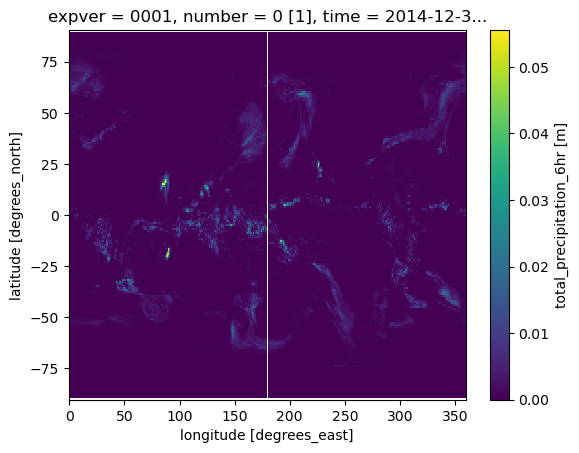

In [80]:
(updated_era5['total_precipitation_6hr'].isel(time=-1)).plot()

In [81]:
# Suppose your variable is called 'precipitation'
var = updated_era5['total_precipitation_6hr']  # shape: (time, lat, lon)

# The longitude to be replaced
target_lon = 180

# Find the index of that longitude
target_lon_idx = np.argmin(np.abs(updated_era5.longitude - target_lon).values)
target_lon_val = updated_era5.longitude[target_lon_idx].values

# Get adjacent longitudes (left and right)
left_lon_idx = target_lon_idx - 1
right_lon_idx = target_lon_idx + 1

# For all latitudes, we want to average the 4 points:
# (lat+1, lon-1), (lat+1, lon+1), (lat-1, lon-1), (lat-1, lon+1)

# We'll loop over latitudes and calculate this for each
lats = updated_era5.latitude
lat_len = len(lats)

new_data = var.copy(deep=True)

for lat_idx in range(1, lat_len - 1):  # skip edge lats
    # Pick 4 neighboring points for this latitude band
    points = [
        var.isel(latitude=lat_idx - 1, longitude=left_lon_idx),
        var.isel(latitude=lat_idx - 1, longitude=right_lon_idx),
        var.isel(latitude=lat_idx + 1, longitude=left_lon_idx),
        var.isel(latitude=lat_idx + 1, longitude=right_lon_idx),
    ]
    
    # Stack and take the mean across the 4 points
    mean_val = xr.concat(points, dim='dummy').mean(dim='dummy')

    # Replace the target longitude value at this latitude
    new_data.loc[dict(latitude=lats[lat_idx], longitude=target_lon_val)] = mean_val
new_data

<xarray.DataArray 'total_precipitation_6hr' (time: 1455, latitude: 181,
                                             longitude: 360)> Size: 758MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
...
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
    expver     (time) <U4 23kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude   (latitude) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * longitude  (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    number     int64 8B 0
  * time       (time) datetime64[ns] 12kB 2014-01-01 ... 2014-12-30T18:00:00
Attributes:
    source:             IMERG daily precipitation converted to 6‑hourly accum...
    original_source:    GPM IMERG Final Precipitation L3 1 day 0.1°×0.1° V07
    conversion_method:  Daily rate (mm/day) → 6‑hr accum. (m)
    units:              m

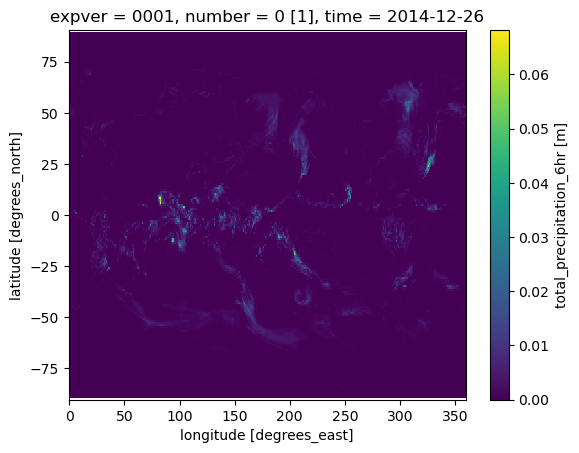

In [82]:
updated_era5['total_precipitation_6hr'] = new_data
updated_era5['total_precipitation_6hr'].isel(time=-20).plot()

In [83]:
imerg_renamed = imerg_ds.rename({'lat': 'latitude', 'lon': 'longitude'})
imerg_renamed

<xarray.Dataset> Size: 381MB
Dimensions:        (time: 365, longitude: 360, latitude: 181)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2014-01-01 ... 2014-12-31
  * latitude       (latitude) float64 1kB -90.0 -89.0 -88.0 ... 88.0 89.0 90.0
  * longitude      (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Data variables:
    precipitation  (time, longitude, latitude) float64 190MB nan 0.0 ... 0.0 nan
    randomError    (time, longitude, latitude) float64 190MB nan 2.765 ... nan
Attributes:
    BeginDate:       2014-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2014-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2014-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20140101-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2024-01-12T13:09:09.320Z

In [84]:
bbox = None
if bbox is None:
    # Default bounding box for India
    bbox = {'lat_min': 5.0, 'lat_max': 35.0, 'lon_min': 65.0, 'lon_max': 100.0}

# Select bounding box for both datasets
era5_sub = updated_era5.sel(
    latitude=slice(bbox['lat_min'], bbox['lat_max']),  # note: lat usually goes from high to low
    longitude=slice(bbox['lon_min'], bbox['lon_max'])
)

imerg_sub = imerg_renamed.sel(
    latitude=slice(bbox['lat_min'], bbox['lat_max']),
    longitude=slice(bbox['lon_min'], bbox['lon_max'])
)

report = []

day = pd.DatetimeIndex(era5_sub.time.values).normalize().unique()[0]

atol = 1e-6

# Normalize IMERG time index to daily

imerg_val = imerg_sub.sel(time=day).precipitation

# Expected ERA5 times within this day (6-hourly: 00, 06, 12, 18)
start = np.datetime64(day)
end = start + np.timedelta64(1, 'D')
era5_times = era5_sub.time
mask = (era5_times >= start) & (era5_times < end)

era5_day_vals = era5_sub["total_precipitation_6hr"].sel(time=era5_times.where(mask, drop=True))

# Sum 6-hourly accumulations to compare with daily total
era5_daily_sum = era5_day_vals.sum(dim="time")

In [85]:

# Difference array (absolute)
diff = np.abs(era5_daily_sum/4 - imerg_val)

max_diff = float(diff.max().values)

if max_diff > atol:
    report.append({
        "date": str(day.date()),
        "max_diff": max_diff,
        "mean_diff": float(diff.mean().values),
    })


if not report:
    print("All ERA5 6-hourly values match IMERG daily values within tolerance.")
else:
    print("Mismatches found on the following days:")
    for r in report:
        print(f"{r['date']}: max diff = {r['max_diff']:.6f}, mean diff = {r['mean_diff']:.6f}")

Mismatches found on the following days:
2014-01-01: max diff = 112.754287, mean diff = 1.923857


In [86]:
import xarray as xr
import numpy as np
import pandas as pd

def verify_era5_matches_imerg_6hrly(updated_era5, imerg_ds, bbox=None, atol=1e-6):
    """
    For each 6-hourly ERA5 timestamp, check if the value equals the IMERG daily
    value converted to m/6hr over a bounding box.
    Assumes each 6-hourly time in a day should have the same value.
    """
    if bbox is None:
        bbox = {'lat_min': 5.0, 'lat_max': 35.0, 'lon_min': 65.0, 'lon_max': 100.0}

    # Slice both datasets to bounding box
    era5 = updated_era5.sel(
        latitude=slice(bbox['lat_min'], bbox['lat_max']),
        longitude=slice(bbox['lon_min'], bbox['lon_max'])
    )
    imerg = imerg_ds.sel(
        latitude=slice(bbox['lat_min'], bbox['lat_max']),
        longitude=slice(bbox['lon_min'], bbox['lon_max'])
    )

    report = []

    # Loop through all 6-hour timestamps
    for t in pd.DatetimeIndex(era5.time.values):
        day = t.normalize()

        try:
            imerg_day = imerg.sel(time=day).precipitation
        except KeyError:
            print(f"Skipping {t}: no IMERG data for {day}")
            continue

        # Convert IMERG to m/6hr
        expected_val = imerg_day * 0.25 * 0.001  # mm/day → m/6hr

        # Get ERA5 value at that timestamp
        era5_val = era5["total_precipitation_6hr"].sel(time=t)

        # Compare the two
        diff = np.abs(era5_val - expected_val)
        max_diff = float(diff.max().values)

        if max_diff > atol:
            report.append({
                "timestamp": str(t),
                "max_diff": max_diff,
                "mean_diff": float(diff.mean().values),
            })

    if not report:
        print("✅ All ERA5 6-hourly values match the converted IMERG values.")
    else:
        print("❌ Mismatches found at these timestamps:")
        for r in report:
            print(f"{r['timestamp']}: max diff = {r['max_diff']:.6e}, mean diff = {r['mean_diff']:.6e}")

    return report


report = verify_era5_matches_imerg_6hrly(updated_era5, imerg_renamed)
report

✅ All ERA5 6-hourly values match the converted IMERG values.


[]

In [87]:
import os
import pandas as pd  
from tqdm import tqdm
import xarray as xr
import numpy as np
import numcodecs
import argparse
import dateparser
import logging
import datetime
import collections
import contextlib
import tree
import queue
import pickle
# faulthandler for dumping stack traces on errors and hangings
import faulthandler
import threading
import concurrent.futures
import gc
import dask
import dask.config
import dask.distributed
import time
import sys
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import graphcast
import graphcast.losses
import graphcast.xarray_jax
from graphcast import checkpoint
sys.path.insert(0,'/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')

from forecast import generate_model
from forecast.models import models_dict
import forecast.encabulator
import trainer.loss_utils
import trainer.grad_utils
import trainer.dataloader

from dist_utils import print_memory_stats, plot_training_metrics, wrap_dataset, split_futures, grad_accumulate, zero_grad_like, stamp, write_opt_checkpoint, write_checkpoint, params_update, data_split, slice_ds


In [88]:
apath= '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache'
start_date= '2014-06-05T00:00:00.000000000'
end_date= '2014-08-25T18:00:00.000000000'
forecast_length= '12'
csvpath= 'training_loss_log.csv'
batch_size= 2
train_batches= 1
model_checkpoint= '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz'
checkpoint_interval= 1
learning_rate= 5e-07
debug= True
debug_memory= True
dry_run= False
jaxlog= False
num_preload= None
opt_checkpoint_interval= 1
cosine_anneal_epochs= [10, 11]
cosine_anneal_end_rate= 5e-09
error_weight_file= None
norm_path= '/Datastorage/saptarishi.dhanuka_asp25/gc_norms'
params_path = model_checkpoint

In [89]:


os.environ["CUDA_VISIBLE_DEVICES"] = "0"


# if ('TF_FORCE_UNIFIED_MEMORY' not in os.environ.keys()):
#     os.environ['TF_FORCE_UNIFIED_MEMORY']='1'
# if ('XLA_CLIENT_MEM_FRACTION' not in os.environ.keys()):
#     os.environ['XLA_CLIENT_MEM_FRACTION'] = '5.0'


# Testing: locking JIT to a single thread may hurt performance with >2 GPUs
jit_lock = threading.Lock()
grad_jitted = collections.defaultdict(lambda : False)

def split_grad(idate,inputs,forcings_list,targets_list,grad_fn,grad_weight,predictor,dask_client):
    # Compute a combined gradient based on split but sequential inputs
    # forcings_list and targets_list are lists of xarrays.  The first entry in these lists
    # must be realized, but the subesequent entires need not be.  This function will use
    # dask_client to compute (load) the data during the gradient and IC calculation.
    global gpu_queue
    global grad_jitted
    global debug_prints
    (params_gpu, grad_accum_gpu, device) = gpu_queue.get()
    tic = datetime.datetime.now()
    
    total_lead_time = sum(t.time.size for t in targets_list)
    loss_accum = 0
    
    inputs_now = wrap_dataset(inputs,device)

    assert(len(targets_list) == len(forcings_list))
    assert(len(targets_list) > 0)

    # Get forcings and targets from the queue, and move them to the GPU
    targets_now = wrap_dataset(targets_list.pop(0),device)
    forcings_now = wrap_dataset(forcings_list.pop(0),device)

    grad_count = 1
    
    while True:
        this_lead = targets_now.time.size
        if (debug_prints):
            dtic1 = datetime.datetime.now()
            print(f'Computing gradient of {stamp(idate)} on {device}, stage {grad_count} for {this_lead} steps')
        if (len(targets_list) > 0):
            # If there are targets left, we'll be continuing the computation
            continue_computation = True
            # In the background, commence loading the next bunch of target/forcing data
            (targets_future,forcings_future) = dask_client.compute((targets_list.pop(0),forcings_list.pop(0)),sync=False)
        else:
            continue_computation = False

        # Compute the gradient over this segment
        with (jit_lock if not grad_jitted[(device,this_lead)] else contextlib.nullcontext()) as _:
            if (debug_prints):
                dtic2 = datetime.datetime.now()
                if ((dtic2-dtic1).total_seconds() > 1):
                    print(f'Commencing gradient computation on {device}, waited {(dtic2-dtic1).total_seconds():.2f}s for compilation lock')
                else: dtic2=dtic1
            (loss_now, _, grad_now) = grad_fn(inputs=inputs_now,forcings=forcings_now,targets = targets_now,params=params_gpu)
            grad_jitted[(device,this_lead)] = True
        # print(f'size {targets_now.time.size} in {(toc-tic).total_seconds():.2f}s')

        # Add the loss and gradient to their accumulators
        
        if (debug_prints):
            dtic3 = datetime.datetime.now()
            print(f'Accumulating gradient on {device} (+{(dtic3-dtic2).total_seconds():.2f}s)')
        loss_accum += loss_now*(targets_now.time.size/total_lead_time)
        grad_accum_gpu = grad_accumulate_jit(grad_now,grad_accum_gpu,grad_weight*this_lead/total_lead_time)        
        if (debug_prints):
            dtic4 = datetime.datetime.now()
            print(f'Gradient accumulated on {device} (+{(dtic4-dtic3).total_seconds():.2f}s)')

        if (continue_computation):
            grad_count += 1
            # Generate the next set of ICs
            inputs_now = future_ics(predictor=predictor,inputs=inputs_now,forcings=forcings_now,targets=targets_now,
                                    params=params_gpu,lead=targets_now.time.size)
            if (debug_prints):
                dtic5 = datetime.datetime.now()
                print(f'New ICs generated on {device} (+{(dtic5-dtic4).total_seconds():.2f}s)')
            # And realize the loading of the next target/forcing data.
            targets_now = wrap_dataset(targets_future.result(),device)
            forcings_now = wrap_dataset(forcings_future.result(),device)
            if (debug_prints):
                dtic6 = datetime.datetime.now()
                print(f'Next targets loaded on {device} (+{(dtic6-dtic5).total_seconds():.2f}s)')
                dtic_last = dtic6
        else:
            if (debug_prints):
                dtic_last=dtic4
            break

        
    gpu_queue.put( (params_gpu, grad_accum_gpu, device) )
    # Uncomment to block this call until the gradient accumulation is completed.
    # With this call commented out, timings may be inaccurate because Jax might return speculatively
    # while commputation is still happening on the GPU; the measured timings might be a better reflection
    # of how long it took to compute the _last_ gradient rather than the current one. 

    # With the call uncommented, timings will be more accurate, but the blocking will eliminate real
    # opportunities to overlap computation with other work, potentially causing a small slowdown.
    
    # next(iter(next(iter(grad_accum_gpu.values())).values())).block_until_ready()
    toc = datetime.datetime.now()
    if (debug_prints):
        print(f'Finished on {device}, {(toc-tic).total_seconds():.2f}s (+{(toc-dtic_last).total_seconds():.2f}s)')
    return (idate, loss_accum, (toc-tic).total_seconds())

# Old gradient update function, not supporting split-horizon gradient computation
# def grad_update(idate,inputs,forcings,targets,grad_fn,grad_weight):
#     # In parallel, execute a prediction and accumulate the gradient to the on-GPU accumulator


#     global gpu_queue
#     global grad_jitted
#     global debug_prints
#     (params_gpu, grad_accum_gpu, device) = gpu_queue.get()
#     tic = datetime.datetime.now()
#     # # Jax's JIT of GraphCast is very spammy thanks to the long compilation times.  We don't
#     # # really want to repeat these messages per GPU.  If the gradient function has not yet
#     # # been compiled, acquire jit_lock to serialize the compilation; everyone who waits on
#     # # this lock should see a faster first-compile through reuse.
#     with (jit_lock if not grad_jitted[device] else contextlib.nullcontext()) as _:
#         if (debug_prints):
#             tic2 = datetime.datetime.now()
#             print(f'Computing gradient on {device=}, {(tic2-tic).total_seconds():.2f}s')
#         new_grad = grad_fn(inputs=inputs, forcings=forcings, targets=targets, params=params_gpu)
#         grad_jitted[device] = True
#     del inputs, forcings, targets
#     if (debug_prints):
#         tic3 = datetime.datetime.now()
#         print(f'Accumulating gradient on {device=}, {(tic3-tic).total_seconds():.2f}s (+{(tic3-tic2).total_seconds():.2f}s)')
#     new_grad_accum_gpu = grad_accumulate_jit(new_grad[2],grad_accum_gpu,grad_weight)
#     # grad_jitted = True
#     err = np.array(new_grad[0])
#     del new_grad
#     gpu_queue.put( (params_gpu, new_grad_accum_gpu, device) )
#     toc = datetime.datetime.now()
#     if (debug_prints):
#         print(f'Finished on {device=}, {(toc-tic).total_seconds():.2f}s (+{(toc-tic3).total_seconds():.2f}s)')
#     return (idate, err, (toc-tic).total_seconds())





def consolidate_grad():
    # Consolidate accumulated gradients between GPU devices
    global gpu_queue
    global params_device
    global grad_accumulate_jit
    accum_grad = None
    for idx in range(len(jax.devices('gpu'))):
        (params, grad, device) = gpu_queue.get(timeout=2)
        grad = jax.device_put(grad,params_device)
        if (accum_grad is None):
            accum_grad = grad
        else:
            accum_grad = grad_accumulate_jit(grad,accum_grad,1.0)
    assert(gpu_queue.empty())
    return accum_grad

def scatter_params(params):
    # Scatter the parameters to each GPU device, posting the paramters
    # and an initialized (zero) gradient accumulator to the device queue
    global gpu_queue

    for device in jax.devices('gpu'):
        # print(f'Scattering parameters to {device=}')
        params_gpu = jax.device_put(params,device)
        accum_gpu = trainer.grad_utils.zero_grad_like(params_gpu)
        gpu_queue.put( (params_gpu, accum_gpu, device) )

device_target_template = collections.defaultdict(lambda : None)

@jax.jit
def stack_inputs(old_input,pred,forcings):
    global input_from_target
    global input_from_forcing
    inputs_next = pred[input_from_target]
    inputs_next[input_from_forcing] = forcings[input_from_forcing]
    for v in inputs_next.data_vars:
        inputs_next[v] = inputs_next[v].transpose(*old_input[v].dims)
    outputs = xr.concat((old_input.isel(time=[1,]),inputs_next),dim='time',coords='minimal',data_vars='minimal')
    outputs['time'] = old_input['time']
    return outputs

def future_ics(predictor,inputs,forcings,targets,params,lead):
    '''Given a predictor function, generate a set of Graphcast-compatible initial conditions
    by taking a basic input and integrating it over a given period, determined by the conventional
    forcings and targets arguments'''

    global debug_prints
    params_device = list(list(list(params.values())[0].values())[0].devices())[0]
    # print(f'Computing ICs {params_device}')
    tic = datetime.datetime.now()
    # Advancing one step at a time, construct initial conditions valid at +lead*6h
    if (device_target_template[params_device] is None):
        device_target_template[params_device] = targets.isel(time=[0,]).copy(deep=True)
        # print(f'Creating target template for {params_device}, loaded on {device_target_template[params_device].geopotential.data.jax_array.device()}')
    targets_template = device_target_template[params_device]
    toc = datetime.datetime.now()
    # print(f'IC setup device {params_device} target template in {(toc-tic).total_seconds():.2f}s')
    tic=toc
    for it in range(lead):
        # forcings_now = forcings.isel(time=[it,])
        # forcings_now['time'] = targets_template['time']
        forcings_now = slice_ds(forcings,it)
        toc = datetime.datetime.now()
        # print(f'IC iter {it} device {params_device} forcings {(toc-tic).total_seconds():.2f}')
        tic=toc
        pred = predictor(inputs=inputs,forcings=forcings_now,targets=targets_template,params=params)
        pred.geopotential.data.jax_array.block_until_ready()
        toc = datetime.datetime.now()
        # print(f'IC iter {it} device {params_device} prediction {(toc-tic).total_seconds():.2f}')
        tic=toc

        inputs = stack_inputs(inputs,pred,forcings_now)
        toc=datetime.datetime.now()
        # print(f'IC iter {it} device {params_device} inputs_next {(toc-tic).total_seconds():.2f}')
        tic=toc
    return inputs

# MAIN FUNCTION HERE ================



In [90]:
start_date= '2014-06-05T00:00:00.000000000'
end_date= '2014-08-25T18:00:00.000000000'

if jax.device_count(backend='gpu') > 0:
    device = jax.devices('gpu')[0]
    print(f'Running with 1 GPU: {device}')
else:
    device = jax.devices('cpu')[0]
    print('Running with CPU only')

# Disable threading inside blosc
numcodecs.blosc.use_threads = False

# Forecast options: forecast length and dataset paths
forecast_lengths = [int(f) for f in forecast_length.split('+')]
assert(all([f > 0 for f in forecast_lengths]))
total_forecast_length = sum(forecast_lengths)
apath = apath

# CSV output path
csvpath = csvpath

num_preload = num_preload

params_path = model_checkpoint
batch_size = batch_size
train_batches = train_batches

numtrain = batch_size*train_batches
learning_rate = learning_rate

use_cosine_annealing = (cosine_anneal_epochs is not None)
if (use_cosine_annealing):
    cosine_warmup = cosine_anneal_epochs[0]
    cosine_total = cosine_anneal_epochs[1]
    if (cosine_anneal_end_rate is not None):
        cosine_end_lr = cosine_anneal_end_rate
    else:
        cosine_end_lr = learning_rate / 100

debug_prints = debug
dry_run = dry_run
trainer.dataloader.debug_prints = debug_prints
debug_print_memory = debug_memory
debug_print_memory_last = datetime.datetime(1970,1,1)

checkpoint_interval = checkpoint_interval
opt_checkpoint_interval = opt_checkpoint_interval

start_date = dateparser.parse(start_date,
                                ['%Y%m%d%H',  # Also parse YYYYMMDDHH (ISO 8601-2004)
                                '%Y%m%d%HZ', # ... with UTC marker
                                '%Y%m%dT%H', # and YYYYMMDDTHH (ISO 8601-2019)
                                '%Y%m%dT%HZ',# ... with UTC marker
                                ])
end_date = dateparser.parse(end_date,
                            ['%Y%m%d%H',  # Also parse YYYYMMDDHH (ISO 8601-2004)
                                '%Y%m%d%HZ', # ... with UTC marker
                                '%Y%m%dT%H', # and YYYYMMDDTHH (ISO 8601-2019)
                                '%Y%m%dT%HZ',# ... with UTC marker
                            ])

# File for user-specified level/variable error weights
error_weight_file = error_weight_file

# Model parameters and checkpoint schema

param_path_components = params_path.split('.')
print(param_path_components)
# initial_batch_number = int(param_path_components[-2])
initial_batch_number = 0
np.random.seed(initial_batch_number)
# param_path_components[-2] = '{batchnum:06d}'
# initial_batch_number = '{batchnum:06d}'
checkpoint_path_schema = '.'.join(param_path_components)

print(f'Using param checkpoint schema {checkpoint_path_schema=}, {initial_batch_number=}')

# Check that we're not trying to train for more batches than a cosine annealing period covers
if (use_cosine_annealing):
    print(f'Using cosine annealing: {cosine_warmup} warmup batches, {cosine_total} total training batches')
    assert(train_batches + initial_batch_number <= cosine_total)



(model_config, task_config, params) = generate_model.load_model(params_path)

dbase,_ = trainer.dataloader.open_databases(apath,None) # Note no need for a separate verification dbase

Running with 1 GPU: cuda:0
['/Datastorage/saptarishi', 'dhanuka_asp25/gc_weights/graphcast_1_13_orig', 'npz']
Using param checkpoint schema checkpoint_path_schema='/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz', initial_batch_number=0
Using cosine annealing: 10 warmup batches, 11 total training batches
Found 41 files in /Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache
Concatenating monthly databases


In [91]:
dbase

<xarray.Dataset> Size: 292GB
Dimensions:                  (time: 4941, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
    expver                   (time) <U4 79kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                   int64 8B ...
  * time                     (time) datetime64[ns] 40kB 2014-01-01 ... 2025-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    land_sea_mask            (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 48GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-05T06:24 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [ ]:
from dist_utils import construct_era5_imerg
updated_era5 = construct_era5_imerg(dbase)
updated_era5

Looping through era5 days for conversion:  71%|███████   | 366/517 [00:07<00:03, 46.90it/s]


Exceeded IMERG timespan, stopped replacing with IMERG
✅ All ERA5 6-hourly values match the converted IMERG values (where IMERG is valid).


<xarray.Dataset> Size: 86GB
Dimensions:                  (time: 1460, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
    expver                   (time) <U4 23kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                   int64 8B 0
  * time                     (time) datetime64[ns] 12kB 2024-01-01 ... 2024-1...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 381MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 381MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 381MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    land_sea_mask            (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 14GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float32 381MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-08-05T06:24 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

: 

In [38]:
len(list(updated_era5.time.values)) == len(set(updated_era5.time.values))

True

In [39]:
updated_era5_cp = updated_era5

In [40]:
updated_era5_cp['total_precipitation_6hr'] = updated_era5_cp['total_precipitation_6hr'].astype('float32')

In [41]:
updated_era5_cp['total_precipitation_6hr'] = (
    updated_era5_cp['total_precipitation_6hr']
    .astype('float32')
    .chunk({'time': 1, 'latitude': 181, 'longitude': 360})
)
updated_era5_cp

<xarray.Dataset> Size: 148GB
Dimensions:                  (time: 2494, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
    expver                   (time) <U4 40kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                   int64 8B 0
  * time                     (time) datetime64[ns] 20kB 2023-01-01 ... 2024-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    land_sea_mask            (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [42]:
dbase, _ = trainer.dataloader.open_databases(apath, None)
dbase

Found ['/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/02', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/03', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/04', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/05', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/06', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/07', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/08', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/09', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/10', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/11', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/12', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/02', '/Datastorage

<xarray.Dataset> Size: 206GB
Dimensions:                  (time: 3482, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
    expver                   (time) <U4 56kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                   int64 8B ...
  * time                     (time) datetime64[ns] 28kB 2023-01-01 ... 2025-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 908MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 908MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 908MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 34GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    land_sea_mask            (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 34GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 34GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float32 908MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 34GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 34GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 34GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [43]:
from dist_utils import same_format_ds
same_format_ds(dbase, updated_era5_cp, check_attrs=False)

(True, 'Datasets have the same format ✅')

In [44]:
# Generate latitude and longitude for the model, based on its resolution
model_latitude = xr.DataArray(np.linspace(-90,90,int(1+180/model_config['resolution']),dtype=np.float32),dims='latitude')
model_latitude = model_latitude.assign_coords({'latitude' : model_latitude})
model_longitude = xr.DataArray(np.linspace(0,360-model_config['resolution'],int(360/model_config['resolution']),dtype=np.float32),
                            dims='longitude')
model_longitude = model_longitude.assign_coords({'longitude' : model_longitude})

input_variables = list(task_config['input_variables'])
target_variables = list(task_config['target_variables'])
forcing_variables = list(task_config['forcing_variables'])

# Define variable sources for future-IC generation
input_only_vars = [v for v in input_variables if v not in target_variables]
global input_from_target
global input_from_forcing
input_from_target = [v for v in input_variables if v in target_variables]
input_from_forcing = [v for v in input_only_vars if v in forcing_variables]

norm_path = norm_path

if (norm_path is not None):
    print(f'Using normalization factors in {norm_path}')
    # Load provided normalization factors
    diffs_stddev_by_level = xr.load_dataset(f"{norm_path}/diffs_stddev_by_level.nc").compute()
    mean_by_level = xr.load_dataset(f"{norm_path}/mean_by_level.nc").compute()
    stddev_by_level = xr.load_dataset(f"{norm_path}/stddev_by_level.nc").compute()
else:
    print(f'Using default normalization factors')
    # Otherwise do not load normalization factors, and default to the loading inside the predictor-generator
    diffs_stddev_by_level = None
    mean_by_level = None
    stddev_by_level = None

# If using custom error weightings, build the appropriate error function
if (error_weight_file is not None):
    print(f'Using custom error weight file {error_weight_file}')
    with open(error_weight_file,'rb') as weightfile:
        (per_variable_weights, level_weights) = pickle.load(weightfile)

        # Re-normalize level weights to have sum of 1; this accounts for loading
        # 37-level weights with a 13-level version of the model
        level_weights = level_weights.sel(level=list(task_config['pressure_levels']))
        level_weights = level_weights / level_weights.sum()

        # The builtin Graphcast loss function operates in the normalized forecast increment space.
        # That means that predicted variables that are also input variables are expressed as
        # (prediction - input)/Δstd, and predicted variables that are not input variables are
        # expressed as (prediction - mean)/std.  We don't care about the mean-subtraction because
        # it applies to both the prediction and the target, but we do need to know whether to divide
        # by the standard deviation of the field or its 6h increment.
        if (diffs_stddev_by_level is None):
            diffs_stddev_by_level = xr.load_dataset("stats/diffs_stddev_by_level.nc").compute()
        if (stddev_by_level is None):
            stddev_by_level = xr.load_dataset('stats/stddev_by_level.nc').compute()
        
        norms_by_level = xr.merge( [ diffs_stddev_by_level[v] if v in input_variables else stddev_by_level[v] \
                                        for v in target_variables ])
        
        latitude_weights = graphcast.losses.normalized_latitude_weights(model_latitude.rename(latitude='lat'))
        latitude_weights = latitude_weights / latitude_weights.mean()

        custom_loss = trainer.loss_utils.make_loss(norms_by_level,per_variable_weights,level_weights,latitude_weights)
else:
    print('Using default error weights')
    custom_loss = None


# Build operators for prediction (forecast generation), GraphCast-style loss computation (builtin,
# averaging losses over lead times), and gradients
predictor = generate_model.build_predictor_params(model_config,task_config,use_float16=False,
                                                    diffs_stddev_by_level = diffs_stddev_by_level, 
                                                    mean_by_level = mean_by_level,
                                                    stddev_by_level = stddev_by_level)
# But keep float32 precision when computing losses alone
loss_fn, _ = generate_model.build_loss_and_grad(model_config, task_config, use_float16=False,custom_loss_fn=custom_loss,
                                                    diffs_stddev_by_level = diffs_stddev_by_level, 
                                                    mean_by_level = mean_by_level,
                                                    stddev_by_level = stddev_by_level)
# Use float16 when computing gradients
_, grad_fn = generate_model.build_loss_and_grad(model_config, task_config, use_float16=True,custom_loss_fn=custom_loss,
                                                    diffs_stddev_by_level = diffs_stddev_by_level, 
                                                    mean_by_level = mean_by_level,
                                                    stddev_by_level = stddev_by_level)

# Jittted function to accumulate gradients
grad_accumulate_jit = jax.jit(grad_accumulate,static_argnums=(2,))

dt = datetime.timedelta(hours=6)
startdate = start_date 
enddate = end_date 
ndates = (enddate-startdate)//dt+1
idx = 0
processed = 0
tic = datetime.datetime.now()

# Initialize loss, gradient, and optimizer



# Set up a GPU queue to hold on-device parameters and gradient accumulation arrays, allowing a grad-calculator
# to run on an available GPU by popping from the queue
# gpu_queue = queue.Queue()
# gpu_device_0 = jax.devices('gpu')[0]
# cpu_device = jax.devices('cpu')[0]
# params_device = gpu_device_0 # cpu_device
# num_gpus = len(jax.devices('gpu')[:1])
# print(f'Running with {num_gpus} GPUs since single threaded')

# params = jax.device_put(params,params_device)

params = jax.device_put(params, device)

if (use_cosine_annealing):
    # Create the optimizer with a cosine-annealing schedule for the learning rate
    print(f'Optimizing with cosine annealing, learning rate {cosine_end_lr:.2e} - {learning_rate:.2e}, {cosine_warmup} warmup batches, and {cosine_total} total batches')
    cosine_schedule = optax.warmup_cosine_decay_schedule(cosine_end_lr, learning_rate, cosine_warmup, cosine_total, end_value=cosine_end_lr, exponent=1.0)
    optimizer = optax.adamw(learning_rate=cosine_schedule,b1=0.9,b2=0.95,weight_decay=0.1,mask=trainer.grad_utils.weight_mask(params))
else:
    # Create the optimizer with a fixed learning rate
    print(f'Optimizing with fixed learning rate {learning_rate:.2e}')
    optimizer = optax.adamw(learning_rate=learning_rate,b1=0.9,b2=0.95,weight_decay=0.1,mask=trainer.grad_utils.weight_mask(params))

# Check to see if an optimizer checkpoint file exists
opt_checkpoint_file = params_path+'.opt'
opt_checkpoint_loaded = False
if (os.path.exists(opt_checkpoint_file)):

    print(f'Attempting to load optimizer state checkpoint {opt_checkpoint_file}')

    try:
        # Load the adamw momentum statistics from the pickled optimizer state file.
        # Everything else (currently the weight mask and cosine schedule counter)
        # can be re-generated easily.
        with open(opt_checkpoint_file,'rb') as ofile:
            opt_state_adamw_loaded = pickle.load(ofile)[0]
            opt_checkpoint_loaded = True
    except Exception as e:
        print(f'Optimizer state load failed, exception {e=}')

opt_state = optimizer.init(params)

if (opt_checkpoint_loaded):
    # Attach the adamw state to the initialized optimizer state, replacing the first
    # field of the tuple
    opt_state = (opt_state_adamw_loaded,) + opt_state[1:]
if (use_cosine_annealing):
    # We want opt_state[2] to reflect the current batch number
    # if (not isinstance(opt_state[2],optax.ScaleByScheduleState) or opt_state[2].count != initial_batch_number):
    print(f'Reseting optimizer epoch count to {initial_batch_number} for cosine annealing')

    opt_state = opt_state[:2] + (optax.ScaleByScheduleState(count = jnp.array([initial_batch_number,],dtype=np.int32)),)
elif (not isinstance(opt_state[2],optax.EmptyState)):
    # Otherwise, we're using a constant learning rate, and opt_state[2] should be an EmptyState.
    # This code will probably not be executed, since we're only applying the adamw information when
    # loading from disk.
    print('Clearing optimizer learning rate state for fixed LR training')
    opt_state = opt_state[:2] + (optax.EmptyState(),)

# Store the optimizer state on the same device as the canonical parameter copy
opt_state = jax.device_put(opt_state,device)



    
if (len(forecast_lengths)>1):
    print(f'Evaluating {numtrain} forecasts of total length {total_forecast_length*6}h',
            f'(split as {"/".join(str(6*h) for h in forecast_lengths)}h)',
            f'between {stamp(startdate)} and {stamp(enddate)}')
else:
    print(f'Evaluating {numtrain} forecasts of total length {total_forecast_length*6}h',
            f' between {stamp(startdate)} and {stamp(enddate)}')



# Set faulthandler to exit the program with a traceback after 15 minutes.  The previous value of 10 minutes was not
# long enough to accommodate the multi-stage JAX compilations for split-horizon gradient calculations.  An initial
# 15-minutes will be re-set to 10 minutes after the first forecast has been processed.
# faulthandler.dump_traceback_later(3600,exit=True)

# =============================================================================================================
"""Single threaded main part"""


# dbase_og, _ = trainer.dataloader.open_databases(apath, None)
# dbase = dbase_og
dbase = updated_era5_cp

# Pre-populate the list of training samples
possible_times = dbase.time.sel(time=slice(startdate, enddate)).data
print(f'Populating training sample list... with possible times: {possible_times[:2]}')
rng = np.random.Generator(np.random.PCG64(seed=0))
# We use a generator so we don't have to store all dates in memory if numtrain is huge
samples_generator = (rng.choice(possible_times).astype('datetime64[s]').astype(datetime.datetime) for _ in range(numtrain))

dbase

Using normalization factors in /Datastorage/saptarishi.dhanuka_asp25/gc_norms
Using default error weights
Optimizing with cosine annealing, learning rate 5.00e-09 - 5.00e-07, 10 warmup batches, and 11 total batches
Reseting optimizer epoch count to 0 for cosine annealing
Evaluating 2 forecasts of total length 72h  between 2023-06-05T00 and 2023-08-25T18
Populating training sample list... with possible times: ['2023-06-05T00:00:00.000000000' '2023-06-05T06:00:00.000000000']


<xarray.Dataset> Size: 148GB
Dimensions:                  (time: 2494, latitude: 181, longitude: 360,
                              level: 37)
Coordinates:
    expver                   (time) <U4 40kB dask.array<chunksize=(1,), meta=np.ndarray>
  * latitude                 (latitude) float64 1kB -90.0 -89.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    number                   int64 8B 0
  * time                     (time) datetime64[ns] 20kB 2023-01-01 ... 2024-0...
Data variables: (12/13)
    10m_u_component_of_wind  (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    2m_temperature           (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    geopotential             (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    land_sea_mask            (latitude, longitude) float32 261kB dask.array<chunksize=(181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    temperature              (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (time, level, latitude, longitude) float32 24GB dask.array<chunksize=(1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (time, latitude, longitude) float32 650MB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [ ]:
test_date = '2014-08-01T00:00:00.000000000'
# Step 1: Convert to numpy.datetime64 with second precision
dt64 = np.datetime64(test_date, 's')
print("datetime64[s]:", dt64)

# Step 2: Convert to Python's datetime.datetime
dt = dt64.astype(datetime.datetime)
print("datetime.datetime:", dt)

datetime64[s]: 2023-08-01T00:00:00
datetime.datetime: 2023-08-01 00:00:00


In [46]:
def build_forecast(idate,forecast_length,task_config,
                   model_latitude, model_longitude, input_variables, target_variables,
                   a_dbase, v_dbase, do_compute = False):
    # from forecast import 
    import forecast.forecast_variables
    from forecast.toa_radiation import toa_radiation
    from forecast import forecast_prep
    from forecast import encabulator
    import datetime
    import numpy as np
    import xarray as xr
    import dask
    import warnings
    dt = datetime.timedelta(hours=6)

    global warned_a_conforming_latlon
    global warned_v_conforming_latlon

    # Work on copies of the databases
    # compute_lock.acquire()
    # a_dbase = a_dbase.copy()
    # v_dbase = v_dbase.copy()
    # compute_lock.release()

    atimes = [idate - dt, idate]
    ftimes = [idate + i*dt for i in range(1,forecast_length+1)]

    atimes_ns = np.array(atimes,dtype='datetime64[ns]')
    ftimes_ns = np.array(ftimes,dtype='datetime64[ns]')
    # print(atimes_ns)

    input_levels = sorted(list(task_config.pressure_levels))

    # Manually convert levels and times to integer indices in the
    # databases, to use .isel rather than .sel for selection.
    try:
        a_level_idx = np.searchsorted(a_dbase.level.data,input_levels)
        assert(all(a_dbase.level.data[a_level_idx] == input_levels))
        
        v_level_idx = np.searchsorted(v_dbase.level.data,input_levels)    
        assert(all(v_dbase.level.data[v_level_idx] == input_levels))

        a_time_idx = np.searchsorted(a_dbase.time.data, atimes_ns)

        print("Printing a_dbase time data")
        print(a_dbase.time.data[a_time_idx])
        print("Atimes_ns")
        print(atimes_ns)




        assert(all(a_dbase.time.data[a_time_idx] == atimes_ns))
        v_time_idx = np.searchsorted(v_dbase.time.data,ftimes_ns)

        print(f"V_Dbase time data: {v_dbase.time.data[v_time_idx]}\n")
        print(f"ftimes_ns: {ftimes_ns}")

        assert(all(v_dbase.time.data[v_time_idx] == ftimes_ns))


    except Exception as e:
        print(f'Error (database availability) when loading forecast of length {forecast_length} for {idate}')
        raise

    # # Create skeletal analysis
    # inputs = xr.Dataset(coords={'time':atimes_ns,
    #                     'level':input_levels,
    #                     'latitude':model_latitude,
    #                     'longitude':model_longitude}) 
    
    # assert(latitude[0] == a_dbase.latitude[0])
    # assert(longitude[0] == a_dbase.longitude[0])

    # Test to see if the model lat/lon exactly match the dataset
    if (model_latitude.size == a_dbase.latitude.size and \
        model_longitude.size == a_dbase.longitude.size and \
        np.all(model_latitude.data == a_dbase.latitude.data) and \
        np.all(model_longitude.data == a_dbase.longitude.data)):
        a_lat_idx = None
        a_lon_idx = None
        a_conforming_latlon = True
    else:
        # Assert that lat/lon of the model are a subset of the dataset
        assert(np.all(np.isin(model_latitude.data,a_dbase.latitude.data)))
        assert(np.all(np.isin(model_longitude.data,a_dbase.longitude.data)))
        # Assert that the database latitude/longitude are in increasing order
        assert(np.all(np.diff(a_dbase.latitude.data) > 0))
        assert(np.all(np.diff(a_dbase.longitude.data) > 0))
        if (not warned_a_conforming_latlon):
            warnings.warn('Analysis/IC dataset is higher resolution than the model; using indexed loading')
            warned_a_conforming_latlon = True
        a_conforming_latlon = False
        a_lat_idx = np.searchsorted(a_dbase.latitude.data,model_latitude.data)
        a_lon_idx = np.searchsorted(a_dbase.longitude.data,model_longitude.data)

    # Test to see if the model lat/lon exactly match the dataset
    if (model_latitude.size == v_dbase.latitude.size and \
        model_longitude.size == v_dbase.longitude.size and \
        np.all(model_latitude.data == v_dbase.latitude.data) and \
        np.all(model_longitude.data == v_dbase.longitude.data)):
        v_lat_idx = None
        v_lon_idx = None
        v_conforming_latlon = True
    else:
        # Assert that lat/lon of the model are a subset of the dataset
        assert(np.all(np.isin(model_latitude.data,v_dbase.latitude.data)))
        assert(np.all(np.isin(model_longitude.data,v_dbase.longitude.data)))
        # Assert that the database latitude/longitude are in increasing order
        assert(np.all(np.diff(v_dbase.latitude.data) > 0))
        assert(np.all(np.diff(v_dbase.longitude.data) > 0))
        if (not warned_v_conforming_latlon):
            warnings.warn('Validation/target dataset is higher resolution than the model; using indexed loading')
            warned_v_conforming_latlon = True
        v_conforming_latlon = False
        v_lat_idx = np.searchsorted(v_dbase.latitude.data,model_latitude.data)
        v_lon_idx = np.searchsorted(v_dbase.longitude.data,model_longitude.data)

    avars_present = list(set.intersection(set(a_dbase.data_vars),input_variables))
    # inputs[avars_present] = a_dbase[avars_present].isel(time=a_time_idx,level=a_level_idx).compute()
    # for var in avars_present:
    #     # print(var)
    #     if 'time' in a_dbase[var].dims:
    #         if 'level' in a_dbase[var].dims:
    #             # XArray "doesn't support yet fancy nd indexing", so we need to slice the data one dimension at a time
    #             if (a_conforming_latlon == True):
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...][:,a_level_idx,:,:])
    #             else:
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...][:,a_level_idx,...][...,a_lat_idx,:][...,a_lon_idx])
    #         else:
    #             if (a_conforming_latlon == True):
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...])
    #             else:
    #                 inputs[var] = (a_dbase[var].dims, a_dbase[var].data[a_time_idx,...][...,a_lat_idx,:][...,a_lon_idx])

    inputs = xr.concat( [dbase_load(a_dbase,avars_present,tt,a_level_idx,a_lat_idx,a_lon_idx) for tt in a_time_idx],
                       coords='minimal',compat='override',dim='time')

    if ('toa_incident_solar_radiation') not in avars_present:
        # Since toa_radiation is being called based on a copy of the input coordinates, we don't
        # have to worry below that time becomes a relative value; contrast the special handling
        # for forcings
        inputs['toa_incident_solar_radiation'] = (('time','latitude','longitude'),
                                                    dask.array.from_delayed(dask.delayed(toa_radiation)(xr.Dataset(inputs.coords.copy())),
                                                                            shape=(inputs.time.size,inputs.latitude.size,inputs.longitude.size),
                                                                            dtype=np.float32))
        
    if ('day_progress_cos' not in avars_present):
        forecast_prep.add_progress(inputs)

        
    forcings = xr.Dataset(coords={'time':ftimes_ns,
                        'level':input_levels,
                        'latitude':model_latitude,
                        'longitude':model_longitude}) 
    # targets = xr.Dataset(coords={'time':ftimes_ns,
    #                     'level':input_levels,
    #                     'latitude':model_latitude,
    #                     'longitude':model_longitude}) 
    tvars_present = list(set.intersection(set(v_dbase.data_vars),target_variables))

    # print(ftimes_ns)

    targets = xr.concat( [dbase_load(v_dbase,tvars_present,tt,v_level_idx,v_lat_idx,v_lon_idx) for tt in v_time_idx],
                        coords='minimal',compat='override',dim='time')
    
    # for var in tvars_present:
    #     if 'time' in v_dbase[var].dims:
    #         if 'level' in v_dbase[var].dims:
    #             if (v_conforming_latlon == True):
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...][:,v_level_idx,...])
    #             else:
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...][:,v_level_idx,...][...,v_lat_idx,:][...,v_lon_idx])
    #         else:
    #             if (v_conforming_latlon == True):
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...])
    #             else:
    #                 targets[var] = (v_dbase[var].dims, v_dbase[var].data[v_time_idx,...][...,v_lat_idx,:][...,v_lon_idx])
    # targets[tvars_present] = v_dbase[tvars_present].isel(time=v_time_idx,level=v_level_idx).compute()

    # As with radiation for the inputs, call toa_radiation on a skeletal dataset made from coordinate copies;
    # this avoids problems when the coordinates are modified subsequently but before(/during?) radiation calculation
    forcings['toa_incident_solar_radiation'] = (('time','latitude','longitude'),
                                                dask.array.from_delayed(dask.delayed(toa_radiation)(xr.Dataset(forcings.coords.copy())),
                                                                        shape=(forcings.time.size,forcings.latitude.size,forcings.longitude.size),
                                                                        dtype=np.float32))
    forecast_prep.add_progress(forcings)

    # Graphcast uses the 'time' dimension for relative time; preserve the original analysis/validity time as
    # a 'datetime' coordinate.
    i_reltime = atimes_ns - atimes_ns[-1]
    inputs['time'] = i_reltime
    inputs.coords['datetime'] = ('time',atimes_ns)

    f_reltime = ftimes_ns - atimes_ns[-1]
    forcings['time'] = f_reltime
    targets['time'] = f_reltime
    forcings.coords['datetime'] = ('time',ftimes_ns)
    targets.coords['datetime'] = ('time',ftimes_ns)

    # Prepend a 'batch' dimension and rename 'latitude' and 'longitude' to 'lat' and 'lon'
    renames = {'latitude': 'lat', 'longitude' : 'lon'}
    inputs = inputs.expand_dims(dim='batch').rename(renames)
    forcings = forcings.expand_dims(dim='batch').rename(renames)
    targets = targets.expand_dims(dim='batch').rename(renames)
    
    fixed_input_vars = set.intersection(set(forecast.forecast_variables.FIXED_VARIABLES),set(input_variables))
    inputs[fixed_input_vars] = inputs[fixed_input_vars].isel(batch=0,time=0,drop=True)

    # inputs, targets, forcings = dask.optimize(inputs,targets,forcings)

    if (do_compute):
        (inputs, forcings, targets) = dask.compute(*(inputs,forcings,targets))
    
    return(inputs, forcings, targets)


In [ ]:
csv_writer = open(csvpath, 'w') if csvpath else contextlib.nullcontext()

with csv_writer as csvfile:
    if csvfile:
        csvfile.write('Batch,Number,Loss\n')
        csvfile.flush()

    # Initialize the gradient accumulator. It will be reset every batch.
    grad_accum = None

    # TODO: Can pass in the paths like suggested instead of the dbase's themselves if it helps with the thread issue
    
    # Loop over each training sample one by one
    training_losses = []
    batch_dates = []

    (inputs, forcings, targets) = build_forecast(
        dt, total_forecast_length, task_config,
        model_latitude, model_longitude, input_variables, target_variables,
        dbase, dbase, do_compute=True)

    # for processed_idx, idate in enumerate(tqdm(samples_generator, total=numtrain, desc="Training Samples")):
    #     (inputs, forcings, targets) = build_forecast(
    #             idate, total_forecast_length, task_config,
    #             model_latitude, model_longitude, input_variables, target_variables,
    #             dbase, dbase, do_compute=True)


    #     continue
    
         
    #     print("Forecast built and computed")
        
        
    #     # Drop datetime coordinate as it's not needed by the model
    #     inputs = inputs.drop_vars('datetime')
    #     forcings = forcings.drop_vars('datetime')
    #     targets = targets.drop_vars('datetime')
        
    #     # Put data on the target device
    #     inputs = wrap_dataset(inputs, device)
    #     forcings = wrap_dataset(forcings, device)
    #     targets = wrap_dataset(targets, device)


    #     print(f"Inputs times: {inputs.time.values[0]} to {inputs.time.values[-1]}")
    #     print(f"Forcings times: {forcings.time.values[0]} to {forcings.time.values[-1]}")
    #     print(f"Targets times: {targets.time.values[0]} to {targets.time.values[-1]}")
        
    #     # --- STEP 2: Compute the gradient directly ---
    #     tic = time.time()
    #     (loss, _, grad) = grad_fn(
    #         inputs=inputs, 
    #         forcings=forcings, 
    #         targets=targets, 
    #         params=params
    #     )
    #     # Ensure computation is finished before timing
    #     loss.block_until_ready()
    #     tictoc = time.time() - tic

    #     # --- STEP 3: Accumulate the gradient ---
    #     if grad_accum is None:
    #         # Initialize the accumulator on the first sample of a batch
    #         grad_accum = zero_grad_like(grad)

    #     # NOTE: grad_fn already sums over the batch dimension if it exists. 
    #     # We add a weight for averaging over the batch.
    #     grad_accum = tree.map_structure(
    #         lambda acc, g: acc + g * (1.0 / batch_size),
    #         grad_accum,
    #         grad
    #     )
        
    #     # --- STEP 4: Logging and Batch Management ---
    #     current_batch_num = initial_batch_number + (processed_idx // batch_size)
    #     current_batch_idx = (processed_idx % batch_size) + 1
        
    #     loss_val = float(loss)
    #     training_losses.append(loss_val)
    #     batch_dates.append(idate)
        
    #     print(f"Sample {processed_idx+1}/{numtrain} | Date: {stamp(idate)} | Loss: {loss_val:.4f} | Grad time: {tictoc:.2f}s")
        
    #     if csvfile:
    #         csvfile.write(f'{current_batch_num},{current_batch_idx},{loss_val:.6e}\n')
        
    #     # --- STEP 5: Update parameters if a batch is complete ---
    #     if current_batch_idx == batch_size:
    #         print(f"\n--- Completing Batch {current_batch_num} ---")
            
    #         # Apply optimizer update
    #         params, opt_state = params_update(optimizer, grad_accum, opt_state, params)
            
    #         # Reset gradient accumulator for the next batch
    #         grad_accum = None 
            
    #         # Checkpointing logic
    #         if checkpoint_interval and (current_batch_num + 1) % checkpoint_interval == 0:
    #             write_checkpoint(checkpoint_path_schema, current_batch_num + 1, params, model_config, task_config)
    #             print(f"Saved model checkpoint for batch {current_batch_num + 1}")
    #         if opt_checkpoint_interval and (current_batch_num + 1) % opt_checkpoint_interval == 0:
    #             write_opt_checkpoint(checkpoint_path_schema, current_batch_num + 1, opt_state)
    #             print(f"Saved optimizer state for batch {current_batch_num + 1}")

    #         if csvfile:
    #             csvfile.flush()
    #         print("--------------------------\n")

    # --- Final actions after the loop ---
    final_batch_num = initial_batch_number + (numtrain - 1) // batch_size
    print("Training finished. Plotting metrics and writing final checkpoint.")
    # plot_training_metrics(training_losses, batch_dates)
    write_checkpoint(checkpoint_path_schema, final_batch_num + 1, params, model_config, task_config)
    write_opt_checkpoint(checkpoint_path_schema, final_batch_num + 1, opt_state)

    print('exiting')    
csv_writer.close()

Printing a_dbase time data
['2023-08-01T00:00:00.000000000' '2023-08-01T00:00:00.000000000']
Atimes_ns
['2023-07-31T18:00:00.000000000' '2023-08-01T00:00:00.000000000']
